# BAU cement NPV simulation

Run the BAU cement Monte Carlo simulation and visualize the resulting NPV distribution.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_technology_npv,
)


In [2]:
TECHNOLOGY = 'bau'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_cement_technology_npv(
    technology=TECHNOLOGY,
    size=SAMPLE_SIZE,
    rng=rng,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,electricity_consumption_mwh_per_t,...,annual_variable_opex_eur,annual_fuel_cost_eur,annual_electricity_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_t,npv_eur_per_t,npv_million_eur_per_t,coal_price_eur_per_mwh_th
0,0,bau,absolute,not_applicable,1000000.0,165.479121,14.937909,5.135369,0.657332,0.084504,...,5.135369e+06,1.060753e+07,2.053590e+07,4.960278e+07,4.918051e+07,3.595119e+08,25000000.0,14.380474,0.000014,16.137240
1,1,bau,absolute,not_applicable,1000000.0,158.777569,14.946918,5.125930,0.649577,0.093378,...,5.125930e+06,8.329445e+06,1.709183e+07,4.820407e+07,5.630181e+07,4.422316e+08,25000000.0,17.689266,0.000018,12.822867
2,2,bau,absolute,not_applicable,1000000.0,167.171958,14.464250,5.431670,0.697878,0.085678,...,5.431670e+06,1.039173e+07,2.164894e+07,5.471230e+07,4.335111e+07,2.955914e+08,25000000.0,11.823657,0.000012,14.890460
3,3,bau,absolute,not_applicable,1000000.0,163.947361,14.001728,5.260010,0.693428,0.089539,...,5.260010e+06,9.695351e+06,1.589668e+07,5.076379e+07,5.438244e+07,4.165730e+08,25000000.0,16.662921,0.000017,13.981771
4,4,bau,absolute,not_applicable,1000000.0,151.883547,14.719678,5.371749,0.694798,0.084480,...,5.371749e+06,6.669512e+06,1.422596e+07,5.222024e+07,5.679286e+07,4.543675e+08,25000000.0,18.174700,0.000018,9.599207


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_t = results["npv_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/t"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/t
count,100000.000000,100000.000000
mean,435.848364,17.433935
std,44.222765,1.768911
min,265.672101,10.626884
5%,363.093601,14.523744
50%,435.727799,17.429112
95%,509.198493,20.367940
max,587.426499,23.497060


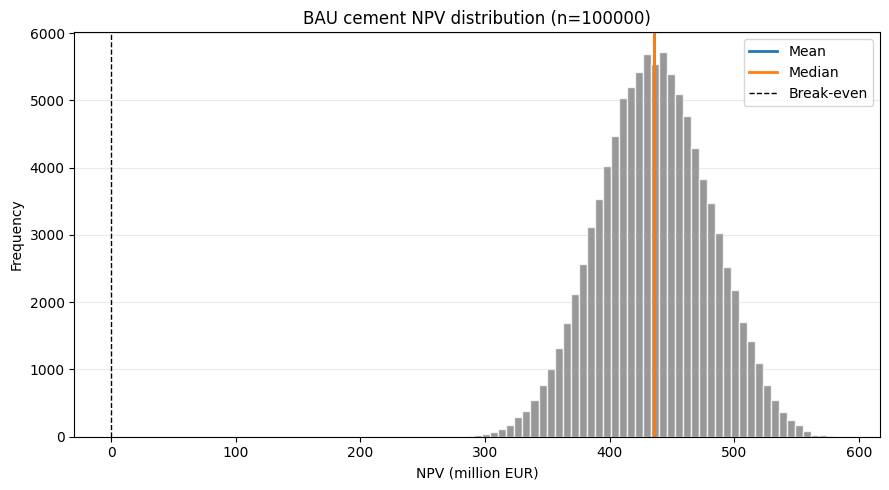

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"BAU cement NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


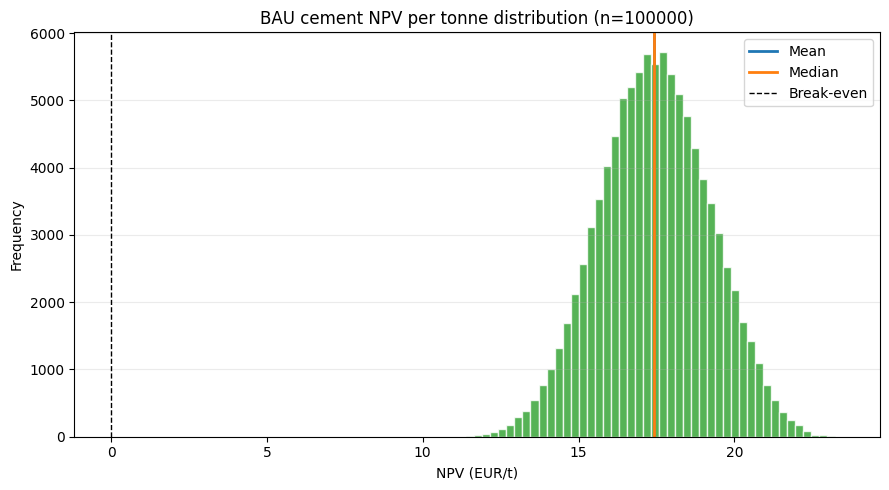

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"BAU cement NPV per tonne distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/t)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           14.332408
annual_variable_opex_eur         5.167223
annual_fuel_cost_eur             8.074949
annual_electricity_cost_eur     15.935731
annual_emissions_cost_eur       50.670171
annual_net_cash_flow_eur        55.819518
Name: Mean annual value, million EUR, dtype: float64